In [1]:
import os
files = os.listdir(r"C:\MyFiles\Project\Formula1_Prediction\data\raw")
print("Files in data/raw:", files)


Files in data/raw: ['circuits.csv', 'constructors.csv', 'constructor_results.csv', 'constructor_standings.csv', 'drivers.csv', 'driver_standings.csv', 'lap_times.csv', 'pit_stops.csv', 'qualifying.csv', 'races.csv', 'results.csv', 'seasons.csv', 'sprint_results.csv', 'status.csv']


# Formula 1 Race Outcome Prediction (Top-10)

Objective: Predict whether a driver will finish in the Top-10 (1) or not (0) for a given race.

Dataset: Formula1 csv files in `C:\MyFiles\Project\Formula1_Prediction\data\raw`. RANDOM_STATE = 42
Models: Logistic Regression, Linear Discriminant Analysis (LDA)
Teacher required outputs: Confusion matrix, Accuracy curve (learning curve), Validation graph (validation curve)


In [2]:
# --- MERGE (no post-race data leakage) ---
import pandas as pd
import numpy as np

DATA_DIR = r"C:\MyFiles\Project\Formula1_Prediction\data\raw"

# Load only necessary pre-race and result files
races = pd.read_csv(f"{DATA_DIR}/races.csv")
results = pd.read_csv(f"{DATA_DIR}/results.csv")
drivers = pd.read_csv(f"{DATA_DIR}/drivers.csv")
constructors = pd.read_csv(f"{DATA_DIR}/constructors.csv")
qual = pd.read_csv(f"{DATA_DIR}/qualifying.csv")
status = pd.read_csv(f"{DATA_DIR}/status.csv")

print("Shapes:")
print("races:", races.shape)
print("results:", results.shape)
print("drivers:", drivers.shape)
print("constructors:", constructors.shape)
print("qualifying:", qual.shape)
print("status:", status.shape)

# --- Merge datasets ---
df = pd.merge(results, races[['raceId','year','round','circuitId','name','date']], on='raceId', how='left')
df = pd.merge(df, drivers[['driverId','forename','surname','dob','nationality']], on='driverId', how='left')
df = pd.merge(df, constructors[['constructorId','constructorRef','name','nationality']],
              on='constructorId', how='left', suffixes=('','_constructor'))

# Rename 'position' in qualifying before merging
qual.rename(columns={'position':'qualifying_position'}, inplace=True)
df = pd.merge(df, qual[['raceId','driverId','qualifying_position']], on=['raceId','driverId'], how='left')

# --- Add Status info (DNF flag) ---
df = pd.merge(df, status[['statusId','status']], on='statusId', how='left')
df['is_dnf'] = np.where(df['status'] != 'Finished', 1, 0)

# --- Filter to modern F1 (2014 onwards) ---
df = df[df['year'] >= 2014].copy()

# --- Calculate driver age ---
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['driver_age'] = (df['date'] - df['dob']).dt.days / 365.25

# --- Target variable (Top10) ---
df['Top10'] = np.where(df['positionOrder'] <= 10, 1, 0)

# --- Handle missing qualifying positions safely ---
df['qualifying_position'] = df['qualifying_position'].fillna(df['grid'])

# --- Drop incomplete rows ---
df.dropna(subset=['grid','driver_age','positionOrder'], inplace=True)

# --- Convert datatypes ---
df['grid'] = df['grid'].astype(int)
df['qualifying_position'] = df['qualifying_position'].astype(int)
df['Top10'] = df['Top10'].astype(int)

df.reset_index(drop=True, inplace=True)
print("✅ Final shape:", df.shape)

# --- Save clean merged dataset ---
df.to_csv(r"C:\MyFiles\Project\Formula1_Prediction\data\merged_clean.csv", index=False)
print("✅ Clean merged file saved as merged_clean.csv")

display(df.head(10))
print("\nTop10 distribution:")
print(df['Top10'].value_counts(normalize=True))


Shapes:
races: (1149, 18)
results: (27158, 18)
drivers: (864, 9)
constructors: (212, 5)
qualifying: (10894, 9)
status: (139, 2)
✅ Final shape: (5025, 35)
✅ Clean merged file saved as merged_clean.csv


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,dob,nationality,constructorRef,name_constructor,nationality_constructor,qualifying_position,status,is_dnf,driver_age,Top10
0,22130,900,3,131,6,3,1,1,1,25.0,...,1985-06-27,German,mercedes,Mercedes,German,3,Finished,0,28.717317,1
1,22131,900,825,1,20,4,2,2,2,18.0,...,1992-10-05,Danish,mclaren,McLaren,British,4,Finished,0,21.442847,1
2,22132,900,18,1,22,10,3,3,3,15.0,...,1980-01-19,British,mclaren,McLaren,British,11,Finished,0,34.154689,1
3,22133,900,4,6,14,5,4,4,4,12.0,...,1981-07-29,Spanish,ferrari,Ferrari,Italian,5,Finished,0,32.629706,1
4,22134,900,822,3,77,15,5,5,5,10.0,...,1989-08-28,Finnish,williams,Williams,British,10,Finished,0,24.547570,1
5,22135,900,807,10,27,7,6,6,6,8.0,...,1987-08-19,German,force_india,Force India,Indian,7,Finished,0,26.573580,1
6,22136,900,8,6,7,11,7,7,7,6.0,...,1979-10-17,Finnish,ferrari,Ferrari,Italian,12,Finished,0,34.412047,1
7,22137,900,818,5,25,6,8,8,8,4.0,...,1990-04-25,French,toro_rosso,Toro Rosso,Italian,6,Finished,0,23.890486,1
8,22138,900,826,5,26,8,9,9,9,2.0,...,1994-04-26,Russian,toro_rosso,Toro Rosso,Italian,8,Finished,0,19.887748,1
9,22139,900,815,10,11,16,10,10,10,1.0,...,1990-01-26,Mexican,force_india,Force India,Indian,16,Finished,0,24.134155,1



Top10 distribution:
Top10
0    0.506468
1    0.493532
Name: proportion, dtype: float64


In [3]:
df.to_csv(r"C:\MyFiles\Project\Formula1_Prediction\data\merged.csv", index=False)
print("✅ Merged file saved as merged.csv")


✅ Merged file saved as merged.csv


Dataset shape: (5025, 35)

Basic statistics:


,grid,qualifying_position,positionOrder,points,driver_age
count,5025.00000,5025.000000,5025.000000,5025.000000,5025.000000
mean,10.36000,10.635423,10.645174,5.017214,27.907996
std,5.91547,5.867128,5.867878,7.227731,5.443524
min,0.00000,0.000000,1.000000,0.000000,17.453799
25%,5.00000,6.000000,6.000000,0.000000,23.731691
50%,10.00000,11.000000,11.000000,0.000000,26.803559
75%,15.00000,16.000000,16.000000,8.000000,31.359343
max,22.00000,22.000000,22.000000,50.000000,44.243669


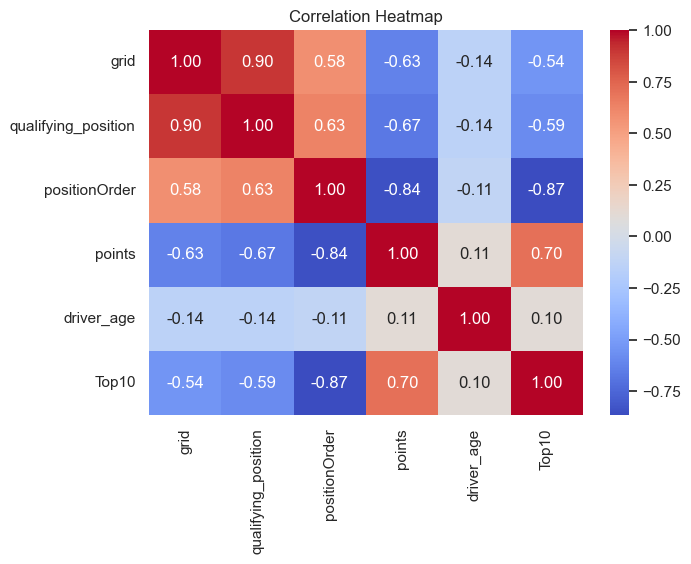

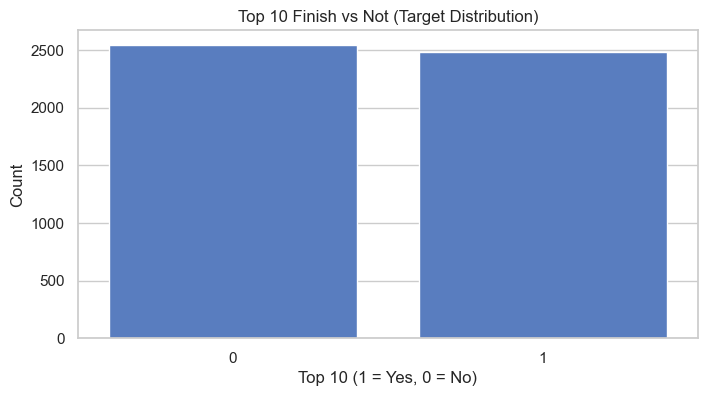

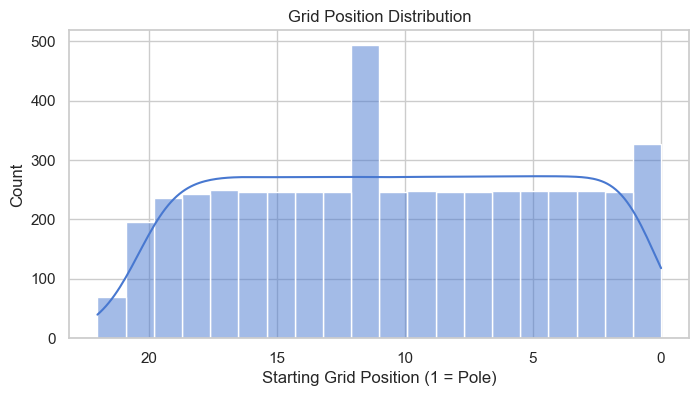

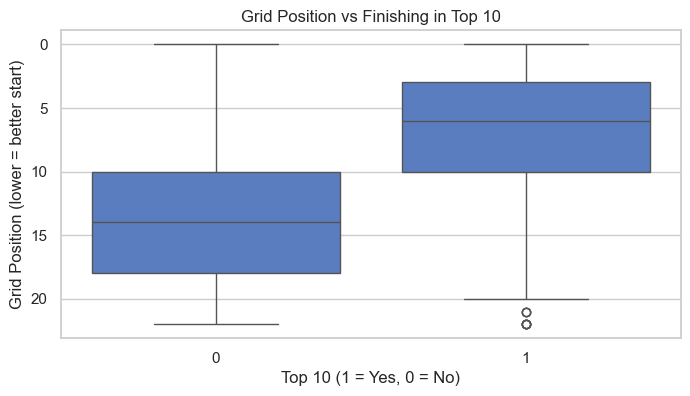

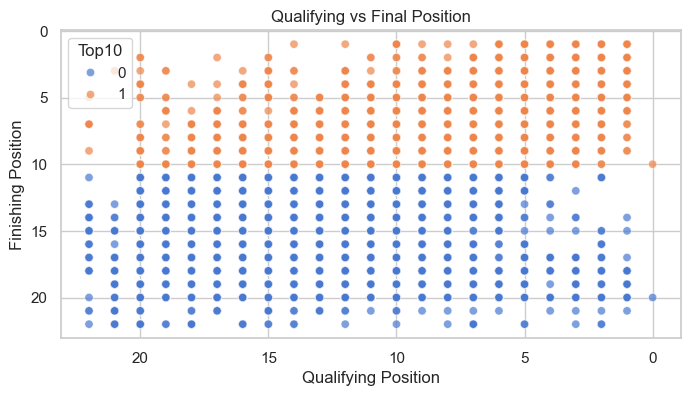

In [4]:
#Basic exploratory data analysis — descriptive stats, correlation heatmap, 
# target balance plot, grid distribution, boxplot and 
# scatter comparing qualifying vs final position.
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = [8, 4]

# --- 1. Basic stats
print("Dataset shape:", df.shape)
print("\nBasic statistics:")
display(df[['grid','qualifying_position','positionOrder','points','driver_age']].describe())

# --- 2. Correlation heatmap
num_cols = ['grid','qualifying_position','positionOrder','points','driver_age','Top10']
plt.figure(figsize=(7,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# --- 3. Count of Top10 vs Not
sns.countplot(x='Top10', data=df)
plt.title("Top 10 Finish vs Not (Target Distribution)")
plt.xlabel("Top 10 (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

# --- 4. Distribution of grid position
sns.histplot(df['grid'], bins=20, kde=True)
plt.title("Grid Position Distribution")
plt.xlabel("Starting Grid Position (1 = Pole)")
plt.gca().invert_xaxis()
plt.show()

# --- 5. Box plot: Grid vs Top10
sns.boxplot(x='Top10', y='grid', data=df)
plt.title("Grid Position vs Finishing in Top 10")
plt.xlabel("Top 10 (1 = Yes, 0 = No)")
plt.ylabel("Grid Position (lower = better start)")
plt.gca().invert_yaxis()
plt.show()

# --- 6. Scatter plot: Qualifying vs Finish
sns.scatterplot(x='qualifying_position', y='positionOrder', hue='Top10', data=df, alpha=0.7)
plt.title("Qualifying vs Final Position")
plt.xlabel("Qualifying Position")
plt.ylabel("Finishing Position")
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.show()


In [5]:
# --- FEATURE ENGINEERING ---
import pandas as pd
import numpy as np

df_feat = df.copy()

# Ensure proper sorting for rolling/expanding calculations
df_feat = df_feat.sort_values(by=['driverId', 'year', 'round']).reset_index(drop=True)

# 1️ Pole position flag
df_feat['is_pole'] = (df_feat['grid'] == 1).astype(int)

# 2️ Driver experience (career races before this one)
df_feat['driver_experience'] = df_feat.groupby('driverId').cumcount()

# 3️ Constructor strength (team average points till that race)
df_feat['constructor_strength'] = (
    df_feat.groupby(['year', 'constructorRef'])['points']
    .transform(lambda x: x.expanding().mean().shift(1))
).fillna(0)

# 4️ Driver recent form — points from last 3 races
df_feat['driver_points_last_3'] = (
    df_feat.groupby('driverId')['points']
    .transform(lambda x: x.rolling(3, min_periods=1).sum().shift(1))
).fillna(0)

# 5️ Constructor recent form — average finish from last 5 races
df_feat['constructor_avg_finish_last_5'] = (
    df_feat.groupby('constructorRef')['positionOrder']
    .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))
).fillna(df_feat['positionOrder'].mean())

# 6️ Driver average finish at each circuit (track familiarity)
circuit_perf = (
    df_feat.groupby(['driverId', 'circuitId'])['positionOrder']
    .apply(lambda x: x.expanding().mean().shift(1))
    .reset_index(level=[0, 1], drop=True)  #  align index back to df_feat
)

df_feat['driver_avg_finish_at_circuit'] = circuit_perf
df_feat['driver_avg_finish_at_circuit'] = df_feat['driver_avg_finish_at_circuit'].fillna(df_feat['positionOrder'].mean())
# 7️ Grid vs qualifying delta (penalties or setup issues)
df_feat['grid_quali_delta'] = df_feat['grid'] - df_feat['qualifying_position']
df_feat['has_penalty'] = (df_feat['grid_quali_delta'] > 3).astype(int)

# 8️ Interaction term — grid × constructor strength
df_feat['grid_x_constructor'] = df_feat['grid'] * df_feat['constructor_strength']

# 9️ Driver recent Top 10 rate (form consistency)
df_feat['driver_top10_rate_last_5'] = (
    df_feat.groupby('driverId')['Top10']
    .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))
).fillna(0)

# 10 Constructor reliability — DNF rate for season
df_feat['constructor_dnf_rate'] = (
    df_feat.groupby(['year', 'constructorRef'])['is_dnf']
    .transform(lambda x: x.rolling(10, min_periods=1).mean().shift(1))
).fillna(0)

# 11 Driver DNF rate (reliability, last 10 races)
df_feat['driver_dnf_rate_last_10'] = (
    df_feat.groupby('driverId')['is_dnf']
    .transform(lambda x: x.rolling(10, min_periods=1).mean().shift(1))
).fillna(0)

# 12 Championship context — cumulative points & rank before race
df_feat['driver_cumulative_points'] = (
    df_feat.groupby(['year', 'driverId'])['points'].cumsum().shift(1).fillna(0)
)
df_feat['driver_champ_rank'] = (
    df_feat.groupby(['year', 'round'])['driver_cumulative_points']
    .rank(ascending=False, method='min')
)

# 13 Points gap to leader
max_points_per_round = df_feat.groupby(['year', 'round'])['driver_cumulative_points'].transform('max')
df_feat['points_from_leader'] = max_points_per_round - df_feat['driver_cumulative_points']


# 14 Safe pit-related trends — based on historical reliability & performance proxies
df_feat['avg_pits_last_5'] = (
    df_feat.groupby('driverId')['is_dnf']
    .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))
).fillna(0)
# (We use DNF rate as a reliability proxy — similar to pit issues historically)

# 15 Safe lap performance proxy — constructor historical average finish time
df_feat['constructor_pace_proxy'] = (
    df_feat.groupby(['year','constructorRef'])['positionOrder']
    .transform(lambda x: x.expanding().mean().shift(1))
).fillna(df_feat['positionOrder'].mean())

# 16 Safe season context (replace driver_standings)
# cumulative points and wins before race (computed, not merged)
df_feat['driver_points_season'] = (
    df_feat.groupby(['year','driverId'])['points'].cumsum().shift(1).fillna(0)
)
df_feat['driver_wins_season'] = (
    df_feat.groupby(['year','driverId'])['positionOrder']
    .transform(lambda x: (x == 1).cumsum().shift(1))
)
df_feat['driver_rank_season'] = (
    df_feat.groupby(['year','round'])['driver_points_season']
    .rank(ascending=False, method='min')
)

# --- Final cleanup ---
df_feat = df_feat.fillna(0)

print("✅ Advanced feature engineering complete! Shape:", df_feat.shape)
display(df_feat.head(10))
# --- Clean non-numeric placeholders ---
df_feat = df_feat.replace("\\N", np.nan)
df_feat = df_feat.apply(pd.to_numeric, errors='ignore')
df_feat = df_feat.fillna(0)

# --- Correlation check with target ---
corr_features = [
    'is_pole','driver_experience','constructor_strength','driver_points_last_3',
    'constructor_avg_finish_last_5','driver_avg_finish_at_circuit','grid_quali_delta',
    'grid_x_constructor','driver_top10_rate_last_5','constructor_dnf_rate',
    'driver_dnf_rate_last_10','driver_cumulative_points','driver_champ_rank',
    'points_from_leader','avg_pits_last_5','constructor_pace_proxy',
    'driver_points_season','driver_rank_season','driver_wins_season','Top10'
]


corr = df_feat[corr_features].corr()['Top10'].sort_values(ascending=False)
print("\nCorrelation of engineered features with Top10:\n")
print(corr)


✅ Advanced feature engineering complete! Shape: (5025, 55)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,constructor_dnf_rate,driver_dnf_rate_last_10,driver_cumulative_points,driver_champ_rank,points_from_leader,avg_pits_last_5,constructor_pace_proxy,driver_points_season,driver_wins_season,driver_rank_season
0,22148,900,1,131,44,1,\N,R,19,0.0,...,0.000000,0.000000,0.0,13.0,385.0,0.000000,10.645174,0.0,0.0,13.0
1,22152,901,1,131,44,1,1,1,1,25.0,...,1.000000,1.000000,0.0,11.0,25.0,1.000000,19.000000,0.0,0.0,11.0
2,22174,902,1,131,44,2,1,1,1,25.0,...,0.500000,0.500000,25.0,2.0,18.0,0.500000,10.000000,25.0,1.0,2.0
3,22196,903,1,131,44,1,1,1,1,25.0,...,0.333333,0.333333,50.0,2.0,11.0,0.333333,7.000000,50.0,2.0,2.0
4,22218,904,1,131,44,1,1,1,1,25.0,...,0.250000,0.250000,75.0,2.0,4.0,0.250000,5.500000,75.0,3.0,2.0
5,22241,905,1,131,44,2,2,2,2,18.0,...,0.200000,0.200000,100.0,1.0,0.0,0.200000,4.600000,100.0,4.0,1.0
6,22278,906,1,131,44,2,\N,R,17,0.0,...,0.166667,0.166667,118.0,2.0,4.0,0.000000,4.166667,118.0,4.0,2.0
7,22285,907,1,131,44,9,2,2,2,18.0,...,0.285714,0.285714,118.0,2.0,22.0,0.200000,6.000000,118.0,4.0,2.0
8,22306,908,1,131,44,6,1,1,1,25.0,...,0.250000,0.250000,136.0,2.0,29.0,0.200000,5.500000,136.0,4.0,2.0
9,22330,909,1,131,44,20,3,3,3,15.0,...,0.222222,0.222222,161.0,2.0,4.0,0.200000,5.000000,161.0,5.0,2.0



Correlation of engineered features with Top10:

Top10                            1.000000
driver_top10_rate_last_5         0.506274
constructor_strength             0.495275
driver_points_last_3             0.469397
driver_points_season             0.410046
driver_cumulative_points         0.410046
driver_wins_season               0.260657
grid_x_constructor               0.251677
is_pole                          0.190388
driver_experience                0.175961
grid_quali_delta                 0.102695
driver_avg_finish_at_circuit    -0.265986
points_from_leader              -0.279212
avg_pits_last_5                 -0.429896
driver_dnf_rate_last_10         -0.459022
constructor_dnf_rate            -0.463512
constructor_avg_finish_last_5   -0.516343
constructor_pace_proxy          -0.533855
driver_champ_rank               -0.540619
driver_rank_season              -0.540619
Name: Top10, dtype: float64


C:\Users\abhin\AppData\Local\Temp\ipykernel_23264\1740494032.py:116: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_feat = df_feat.apply(pd.to_numeric, errors='ignore')


Logistic Regression Accuracy: 0.776
LDA Accuracy: 0.783


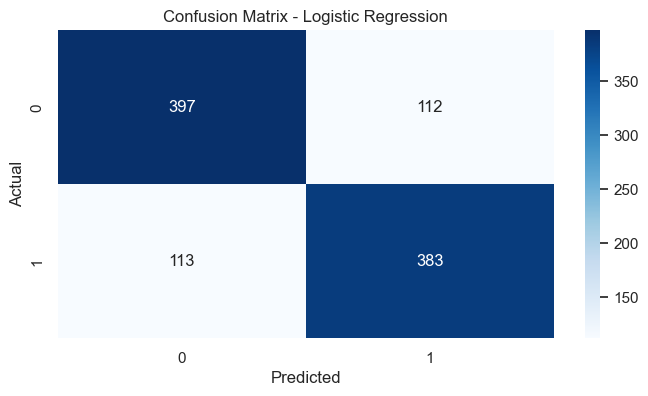

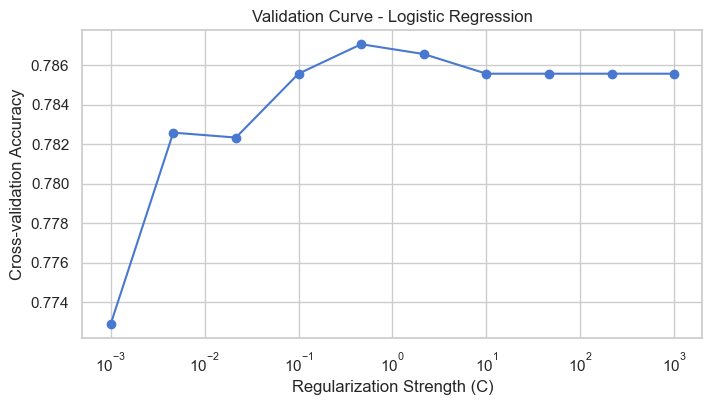

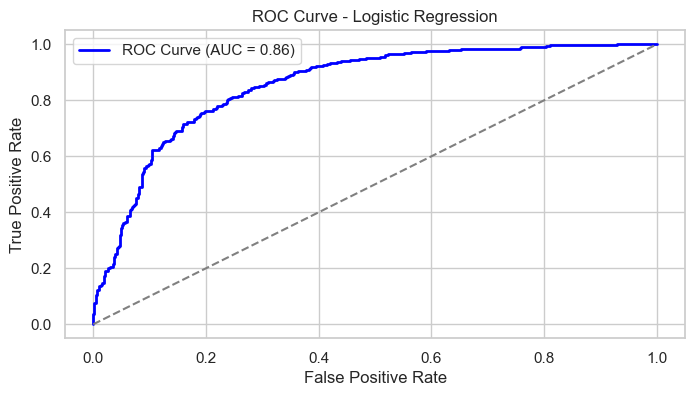

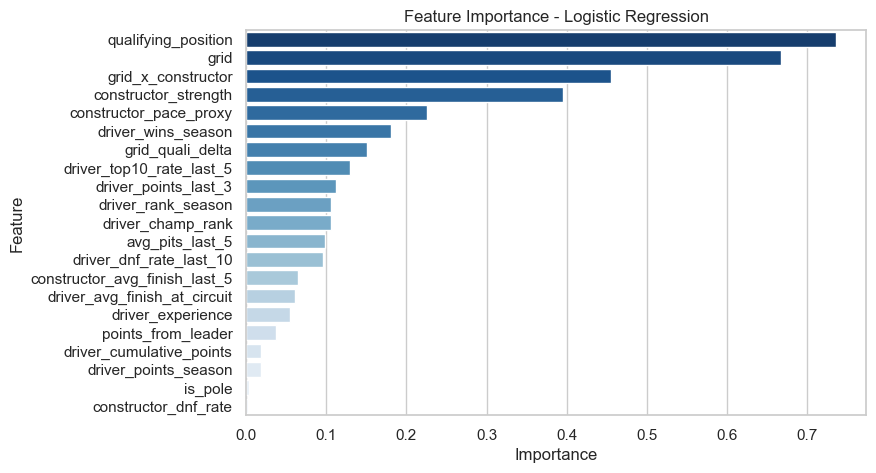

In [6]:
#Logistic Regression and Linear Discriminant Analysis models
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- Prepare data ---
features = [
    'grid', 'qualifying_position', 'is_pole', 'driver_experience',
    'driver_top10_rate_last_5', 'driver_points_last_3', 'driver_points_season',
    'driver_cumulative_points', 'driver_wins_season',
    'constructor_strength', 'constructor_avg_finish_last_5', 'constructor_dnf_rate',
    'driver_dnf_rate_last_10',
    'driver_avg_finish_at_circuit', 'grid_quali_delta', 'grid_x_constructor',
    'avg_pits_last_5', 'constructor_pace_proxy',
    'driver_rank_season', 'driver_champ_rank', 'points_from_leader'
]
X = df_feat[features]
y = df_feat['Top10']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 1 Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

# --- 2 Linear Discriminant Analysis ---
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)
y_pred_lda = lda.predict(X_test_scaled)

# --- Evaluation ---
acc_log = accuracy_score(y_test, y_pred_log)
acc_lda = accuracy_score(y_test, y_pred_lda)
print(f"Logistic Regression Accuracy: {acc_log:.3f}")
print(f"LDA Accuracy: {acc_lda:.3f}")

# --- Confusion Matrix (Logistic Regression) ---
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- Validation Curve (Cross-validation) ---
C_values = np.logspace(-3, 3, 10)
cv_scores = [cross_val_score(LogisticRegression(C=c, max_iter=1000, random_state=42),
                             X_train_scaled, y_train, cv=5).mean() for c in C_values]

plt.semilogx(C_values, cv_scores, marker='o')
plt.xlabel("Regularization Strength (C)")
plt.ylabel("Cross-validation Accuracy")
plt.title("Validation Curve - Logistic Regression")
plt.show()

# --- ROC Curve (optional bonus plot) ---
y_prob = log_reg.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()
# --- Feature Importance (Logistic Regression) ---
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(log_reg.coef_[0])
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance, hue='Feature', palette='Blues_r', legend=False)
plt.title("Feature Importance - Logistic Regression")
plt.show()


Random Forest Accuracy: 0.772
Cross-validation Accuracy: 0.777
Random Forest ROC-AUC: 0.851


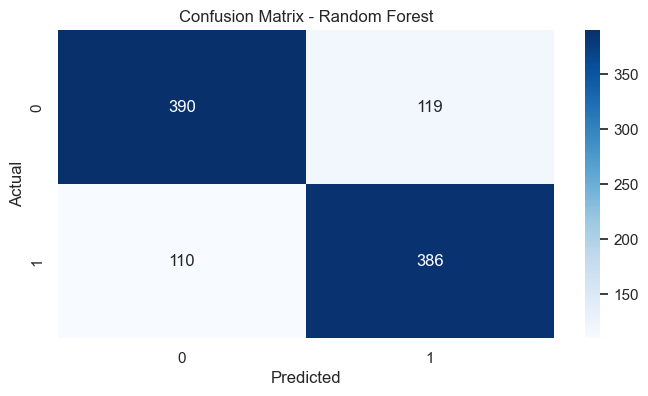

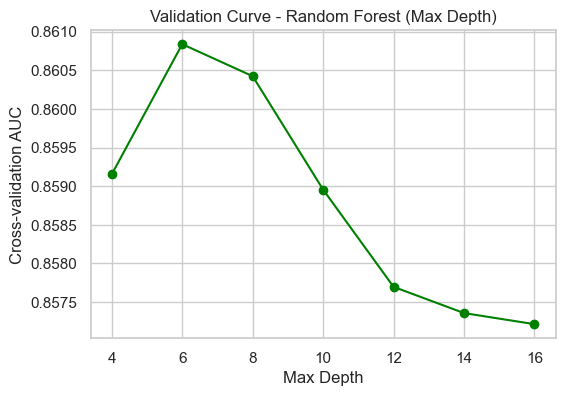

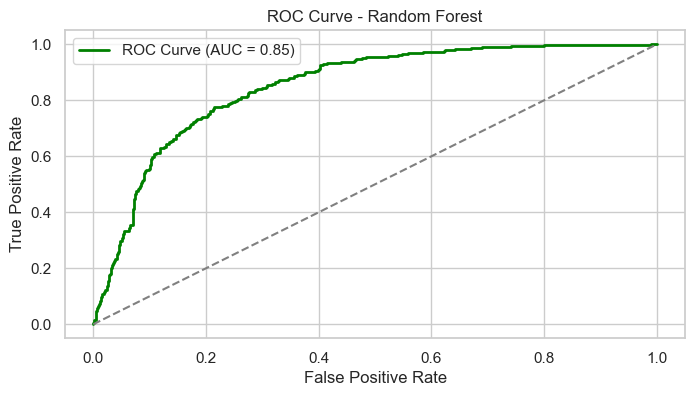

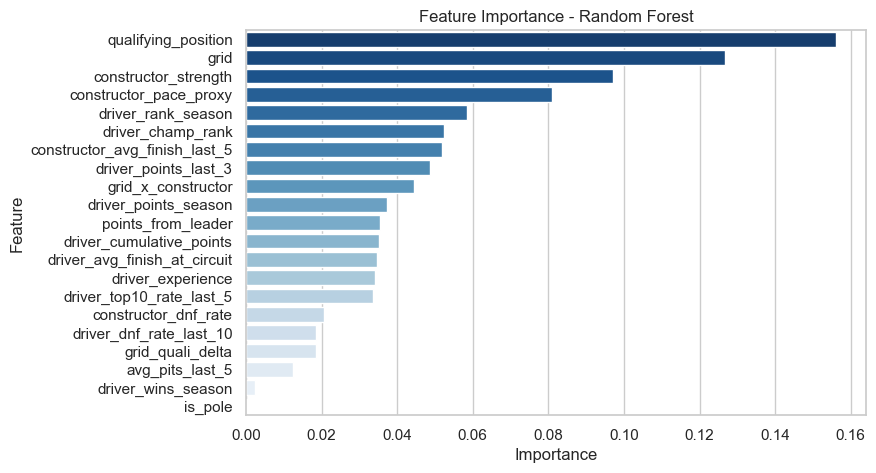

In [7]:
# --- Random Forest Model for Top10 Prediction ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- Prepare data ---
features = [
    'grid', 'qualifying_position', 'is_pole', 'driver_experience',
    'driver_top10_rate_last_5', 'driver_points_last_3', 'driver_points_season',
    'driver_cumulative_points', 'driver_wins_season',
    'constructor_strength', 'constructor_avg_finish_last_5', 'constructor_dnf_rate',
    'driver_dnf_rate_last_10',
    'driver_avg_finish_at_circuit', 'grid_quali_delta', 'grid_x_constructor',
    'avg_pits_last_5', 'constructor_pace_proxy',
    'driver_rank_season', 'driver_champ_rank', 'points_from_leader'
]
X = df_feat[features]
y = df_feat['Top10']

# Split into training and test sets (same split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# --- 1 Train Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# --- 2 Predictions & Evaluation ---
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
cv_score_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy').mean()

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr, tpr)

print(f"Random Forest Accuracy: {acc_rf:.3f}")
print(f"Cross-validation Accuracy: {cv_score_rf:.3f}")
print(f"Random Forest ROC-AUC: {roc_auc_rf:.3f}")

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# --- Validation Curve (Max Depth tuning) ---
from sklearn.model_selection import cross_val_score
import numpy as np

max_depth_values = [4, 6, 8, 10, 12, 14, 16]
cv_scores = []

for depth in max_depth_values:
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=depth,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    )
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()
    cv_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(max_depth_values, cv_scores, marker='o', color='green')
plt.xlabel("Max Depth")
plt.ylabel("Cross-validation AUC")
plt.title("Validation Curve - Random Forest (Max Depth)")
plt.grid(True)
plt.show()


# --- ROC Curve ---
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC Curve (AUC = {roc_auc_rf:.2f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

# --- Feature Importance ---
import pandas as pd
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance, hue='Feature', palette='Blues_r', legend=False)

plt.title("Feature Importance - Random Forest")
plt.show()


In [8]:
# --- HYPERPARAMETER TUNING: XGBoost ---
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

# Define parameter search space
param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2],
    'min_child_weight': [1, 3, 5],
}

# Initialize base model
xgb_tune = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# Randomized search with 5-fold CV
search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

print(" Running XGBoost hyperparameter tuning...")
search.fit(X_train, y_train)

# Save tuned params for next cell
best_params = search.best_params_
best_auc = search.best_score_

print("\n Best Parameters Found:")
print(best_params)
print(f"Best Cross-Validation ROC-AUC: {best_auc:.3f}")


 Running XGBoost hyperparameter tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

 Best Parameters Found:
{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}
Best Cross-Validation ROC-AUC: 0.861


XGBoost Accuracy: 0.778
Cross-validation Accuracy: 0.779
XGBoost ROC-AUC: 0.859


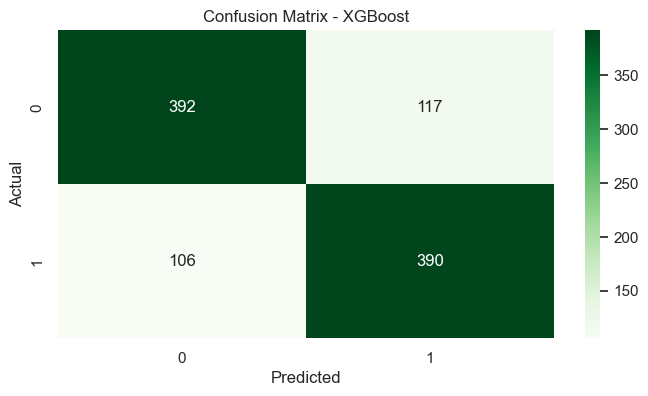

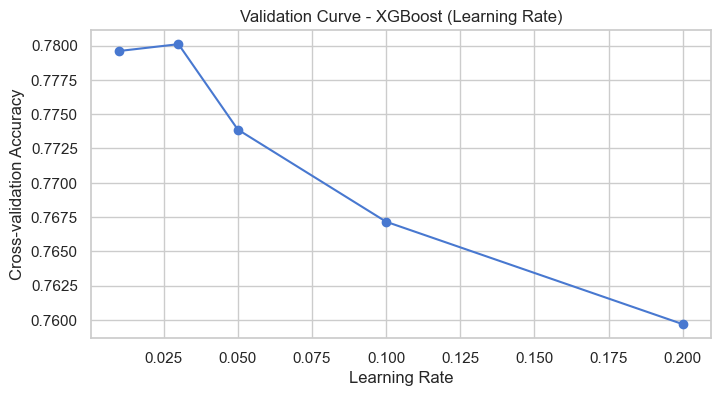

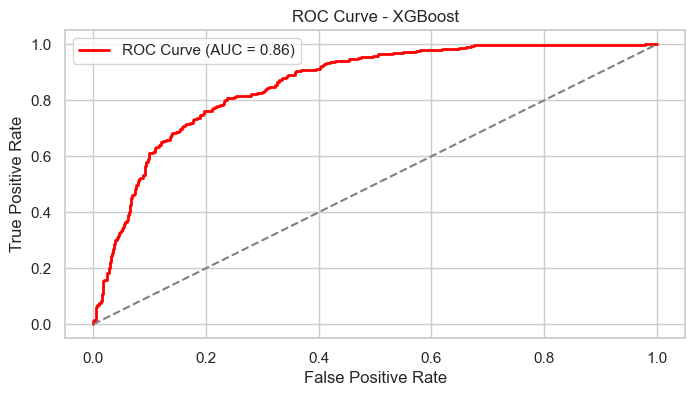

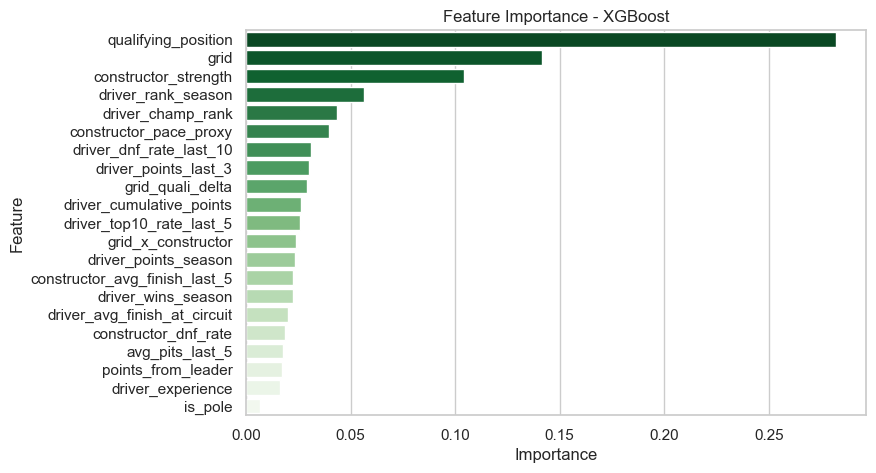

In [9]:
# --- XGBoost Model for Top10 Prediction ---
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Prepare data ---
features = [
    'grid', 'qualifying_position', 'is_pole', 'driver_experience',
    'driver_top10_rate_last_5', 'driver_points_last_3', 'driver_points_season',
    'driver_cumulative_points', 'driver_wins_season',
    'constructor_strength', 'constructor_avg_finish_last_5', 'constructor_dnf_rate',
    'driver_dnf_rate_last_10',
    'driver_avg_finish_at_circuit', 'grid_quali_delta', 'grid_x_constructor',
    'avg_pits_last_5', 'constructor_pace_proxy',
    'driver_rank_season', 'driver_champ_rank', 'points_from_leader'
]
X = df_feat[features]
y = df_feat['Top10']

# Split into training and test sets (same split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# --- 1️ Train Tuned XGBoost Model ---
xgb = XGBClassifier(
    **best_params,          #  Uses the tuned values automatically
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

# --- 2️ Predictions & Evaluation ---
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {acc_xgb:.3f}")

# --- Cross-validation accuracy ---
cv_score_xgb = cross_val_score(xgb, X_train, y_train, cv=5, scoring='accuracy').mean()
print(f"Cross-validation Accuracy: {cv_score_xgb:.3f}")

# --- ROC-AUC ---
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)
print(f"XGBoost ROC-AUC: {roc_auc:.3f}")

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- Validation Curve (Learning Rate tuning) ---
from sklearn.model_selection import cross_val_score

learning_rates = [0.01, 0.03, 0.05, 0.1, 0.2]
cv_scores = []

for lr in learning_rates:
    model = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=lr,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        eval_metric='logloss'
    )
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    cv_scores.append(score)

plt.plot(learning_rates, cv_scores, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Cross-validation Accuracy")
plt.title("Validation Curve - XGBoost (Learning Rate)")
plt.show()

# --- ROC Curve ---
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

# --- Feature Importance ---
import pandas as pd
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance, hue='Feature', palette='Greens_r', legend=False)

plt.title("Feature Importance - XGBoost")
plt.show()


In [10]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Predictions on train data
y_train_pred_xgb = xgb.predict(X_train)
y_train_prob_xgb = xgb.predict_proba(X_train)[:, 1]

# Predictions on test data (already computed earlier)
y_test_pred_xgb = y_pred_xgb
y_test_prob_xgb = y_prob_xgb

# Compute metrics
train_acc_xgb = accuracy_score(y_train, y_train_pred_xgb)
train_auc_xgb = roc_auc_score(y_train, y_train_prob_xgb)
test_acc_xgb = accuracy_score(y_test, y_test_pred_xgb)
test_auc_xgb = roc_auc_score(y_test, y_test_prob_xgb)

# Print comparison
print("Train Accuracy:", train_acc_xgb)
print("Train ROC-AUC:", train_auc_xgb)
print("Test Accuracy:", test_acc_xgb)
print("Test ROC-AUC:", test_auc_xgb)

# Quick health interpretation
gap_acc = train_acc_xgb - test_acc_xgb
gap_auc = train_auc_xgb - test_auc_xgb

if gap_auc < 0.04 and gap_acc < 0.07:
    print("\n✅ Model is well-generalized (healthy fit).")
elif gap_auc < 0.08:
    print("\n⚠️ Mild overfitting — acceptable for boosting models.")
else:
    print("\n🚨 Possible overfitting detected — consider more regularization.")


Train Accuracy: 0.8087064676616915
Train ROC-AUC: 0.8878171739337093
Test Accuracy: 0.7781094527363184
Test ROC-AUC: 0.8587640218011281

✅ Model is well-generalized (healthy fit).


In [11]:
# --- Hyperparameter Tuning: CatBoost ---
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

print("🔍 Running CatBoost hyperparameter tuning...")

# Define base model
cat_base = CatBoostClassifier(
    eval_metric='AUC',
    verbose=0,
    random_seed=42
)

# Define parameter grid
param_dist = {
    'depth': [4, 5, 6, 7, 8, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'iterations': [200, 300, 400, 500, 700],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'border_count': [32, 64, 128],
    'bagging_temperature': [0, 0.25, 0.5, 1],
    'random_strength': [1, 2, 5, 10]
}

# Compute sample weights (if data is imbalanced)
weights = compute_sample_weight('balanced', y_train)

# RandomizedSearchCV setup
search_cat = RandomizedSearchCV(
    estimator=cat_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# Run search
search_cat.fit(X_train, y_train, sample_weight=weights)

# Save best parameters globally
best_cat_params = search_cat.best_params_

print("\n✅ Best Parameters Found:")
print(best_cat_params)
print(f"Best Cross-Validation ROC-AUC: {search_cat.best_score_:.3f}")


🔍 Running CatBoost hyperparameter tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ Best Parameters Found:
{'random_strength': 5, 'learning_rate': 0.01, 'l2_leaf_reg': 7, 'iterations': 700, 'depth': 5, 'border_count': 64, 'bagging_temperature': 0.5}
Best Cross-Validation ROC-AUC: 0.862


✅ Using best hyperparameters from tuning...
CatBoost Accuracy: 0.777
CatBoost ROC-AUC: 0.857


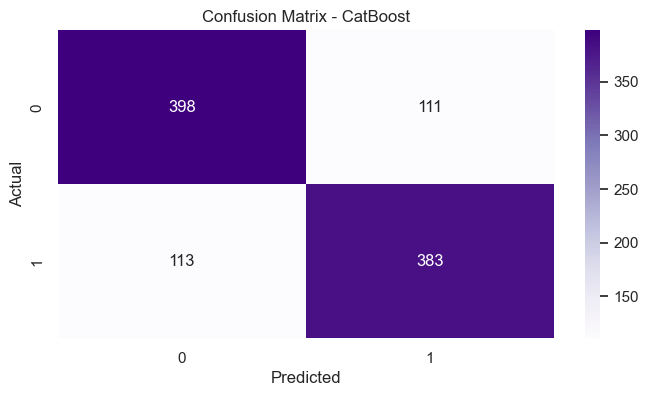

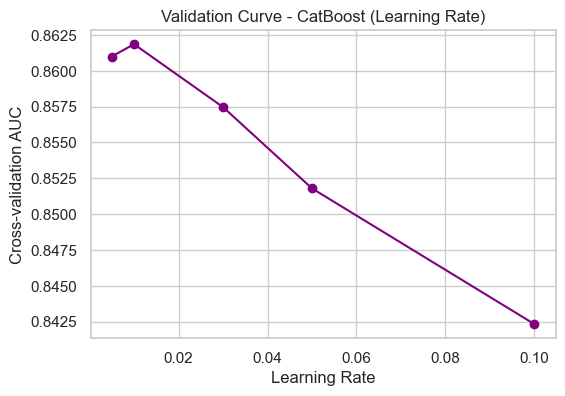

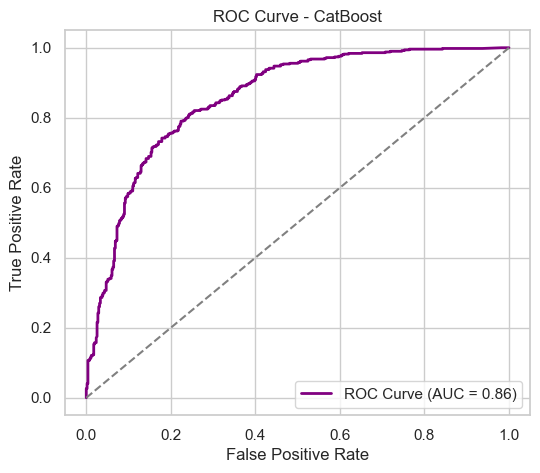

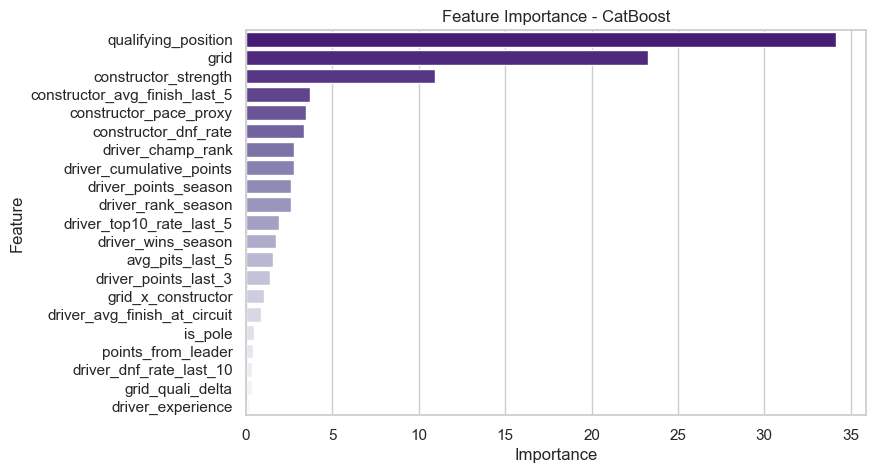

In [12]:
# --- CatBoost Model for Top10 Prediction (Auto-param from tuning) ---
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Use best params from tuning if available ---
try:
    params = best_cat_params.copy()
    print("✅ Using best hyperparameters from tuning...")
except NameError:
    print("⚠️ No tuned parameters found. Using default values.")
    params = {
        'depth': 4,
        'learning_rate': 0.01,
        'iterations': 700,
        'l2_leaf_reg': 9,
        'border_count': 32,
        'bagging_temperature': 1,
        'random_strength': 1
    }

# Add static parameters (silent training)
params.update({
    'eval_metric': 'AUC',
    'early_stopping_rounds': 50,
    'random_seed': 42,
    'verbose': False  # 👈 suppress logs
})

# Train model silently
cat_model = CatBoostClassifier(**params)
cat_model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# Predictions & Evaluation
y_pred_cat = cat_model.predict(X_test)
y_prob_cat = cat_model.predict_proba(X_test)[:, 1]

acc_cat = accuracy_score(y_test, y_pred_cat)
roc_auc_cat = roc_auc_score(y_test, y_prob_cat)

print(f"CatBoost Accuracy: {acc_cat:.3f}")
print(f"CatBoost ROC-AUC: {roc_auc_cat:.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_cat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - CatBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Validation Curve (Learning Rate)
learning_rates = [0.005, 0.01, 0.03, 0.05, 0.1]
cv_scores = []
for lr in learning_rates:
    model = CatBoostClassifier(**{**params, 'learning_rate': lr})
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()
    cv_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(learning_rates, cv_scores, marker='o', color='purple')
plt.xlabel("Learning Rate")
plt.ylabel("Cross-validation AUC")
plt.title("Validation Curve - CatBoost (Learning Rate)")
plt.grid(True)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_cat)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CatBoost")
plt.legend()
plt.show()

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': cat_model.get_feature_importance()
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance, hue='Feature', palette='Purples_r', legend=False)
plt.title("Feature Importance - CatBoost")
plt.show()


In [13]:
y_train_pred = cat_model.predict(X_train)
y_train_prob = cat_model.predict_proba(X_train)[:,1]

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Train ROC-AUC:", roc_auc_score(y_train, y_train_prob))
print("Test Accuracy:", acc_cat)
print("Test ROC-AUC:", roc_auc_cat)

Train Accuracy: 0.7860696517412935
Train ROC-AUC: 0.8621236592147792
Test Accuracy: 0.7771144278606965
Test ROC-AUC: 0.8572568762278978
